# Autoencoder

librerias

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


Carga dataset Fashion MNIST

In [2]:
#

transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

class_names = np.array(['T-shirt/top', 'Trouser/pants', 'Pullover shirt', 'Dress',
                        'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.67MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]


Muestra un par de instancias

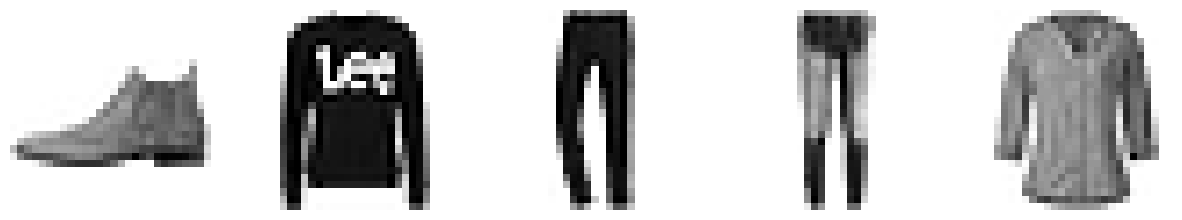

In [4]:
#

n_examples = 1000
example_images, example_labels = next(iter(test_loader))
example_images = example_images[:n_examples]
example_labels = example_labels[:n_examples].numpy()

f, axs = plt.subplots(1, 5, figsize=(15, 4))
for j in range(len(axs)):
    axs[j].imshow(example_images[j].view(28, 28).numpy(), cmap='binary')
    axs[j].axis('off')

Encoder

In [6]:
#

encoded_dim = 2

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.Sigmoid(),
            nn.Linear(256, 128),
            nn.Sigmoid(),
            nn.Linear(128, 64),
            nn.Sigmoid(),
            nn.Linear(64, encoded_dim)
        )

    def forward(self, x):
        return self.model(x)

encoder = Encoder()
encoder

Encoder(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): Sigmoid()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): Sigmoid()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): Sigmoid()
    (7): Linear(in_features=64, out_features=2, bias=True)
  )
)

Prueba el decoder solo antes de entrenar, para ver variables lantentes sin aprendizaje.

In [8]:
#

with torch.no_grad():
    pretrain_example_encodings = encoder(example_images)

Grafica las variables latentes sin aprendizaje (aleatorias)

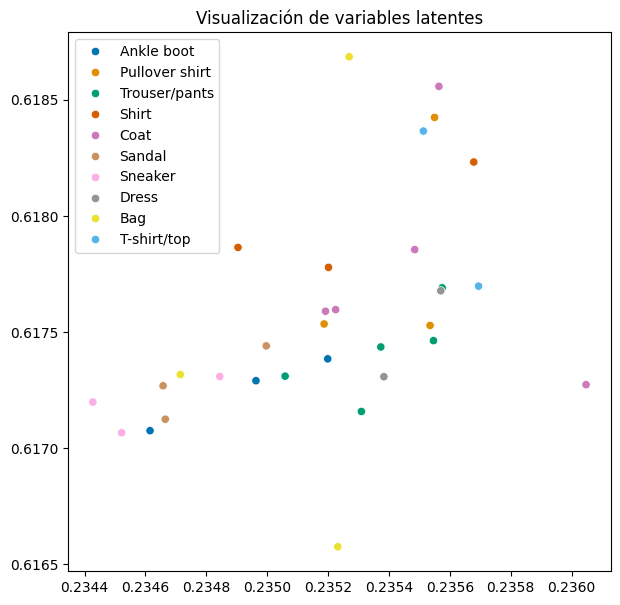

In [9]:
#

f, ax = plt.subplots(1, 1, figsize=(7, 7))
sns.scatterplot(x=pretrain_example_encodings[:, 0].numpy(),
                y=pretrain_example_encodings[:, 1].numpy(),
                hue=class_names[example_labels], ax=ax,
                palette=sns.color_palette("colorblind", 10))
ax.set_title('Visualización de variables latentes');

Decoder

In [10]:
#
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(encoded_dim, 64),
            nn.Sigmoid(),
            nn.Linear(64, 128),
            nn.Sigmoid(),
            nn.Linear(128, 256),
            nn.Sigmoid(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),
            nn.Unflatten(1, (28, 28))
        )

    def forward(self, x):
        return self.model(x)

decoder = Decoder()
decoder

Decoder(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=256, out_features=784, bias=True)
    (7): Sigmoid()
    (8): Unflatten(dim=1, unflattened_size=(28, 28))
  )
)

Integración de la arquitectura en autoencoder

In [11]:
#
class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(Autoencoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = Autoencoder(encoder, decoder)
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (model): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=784, out_features=256, bias=True)
      (2): Sigmoid()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): Sigmoid()
      (5): Linear(in_features=128, out_features=64, bias=True)
      (6): Sigmoid()
      (7): Linear(in_features=64, out_features=2, bias=True)
    )
  )
  (decoder): Decoder(
    (model): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): Sigmoid()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): Sigmoid()
      (4): Linear(in_features=128, out_features=256, bias=True)
      (5): Sigmoid()
      (6): Linear(in_features=256, out_features=784, bias=True)
      (7): Sigmoid()
      (8): Unflatten(dim=1, unflattened_size=(28, 28))
    )
  )
)


Comlpilación y Fit del autoencoder, todo entrena junto.

In [14]:
criterion = nn.BCELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

In [16]:
autoencoder.train()
for epoch in range(30):
    for data in train_loader:
        img, _ = data
        optimizer.zero_grad()
        output = autoencoder(img)
        loss = criterion(output.view(output.size(0), -1), img)
        loss.backward()
        optimizer.step()

Solo econder para generar variables latentes

In [17]:
#

with torch.no_grad():
    posttrain_example_encodings = encoder(example_images)

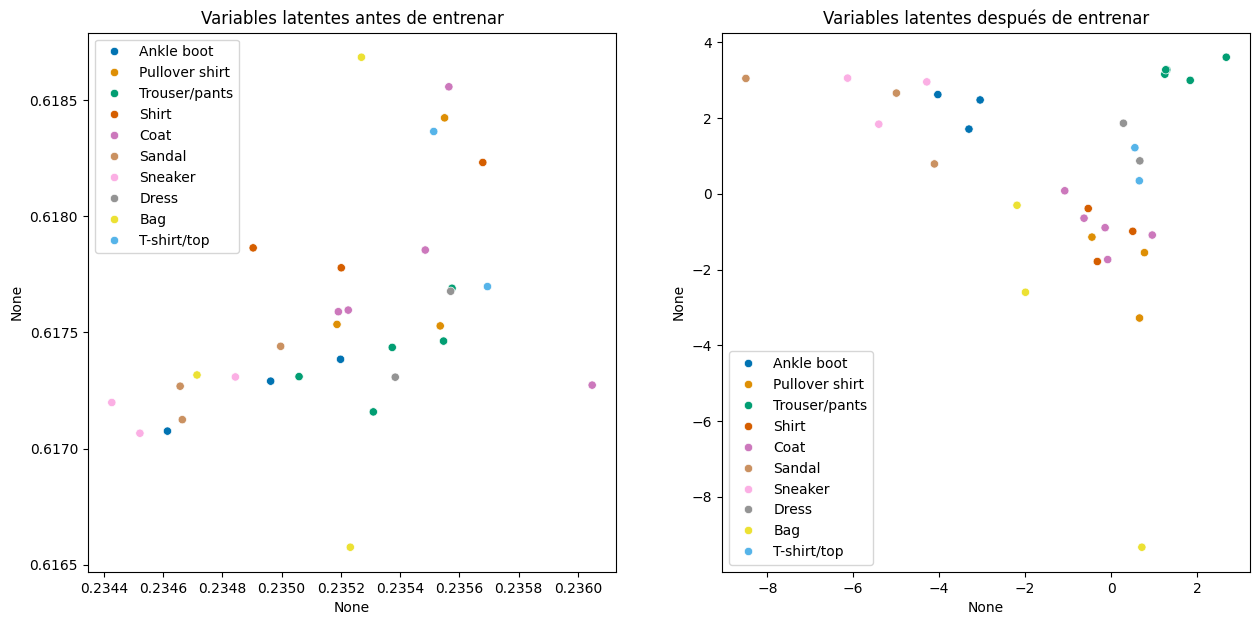

In [18]:
#

f, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
sns.scatterplot(x = pretrain_example_encodings[:, 0],
                y = pretrain_example_encodings[:, 1],
                hue=class_names[example_labels], ax=axs[0],
                palette=sns.color_palette("colorblind", 10))

sns.scatterplot(x = posttrain_example_encodings[:, 0],
                y = posttrain_example_encodings[:, 1],
                hue=class_names[example_labels], ax=axs[1],
                palette=sns.color_palette("colorblind", 10))


axs[0].set_title('Variables latentes antes de entrenar');
axs[1].set_title('Variables latentes después de entrenar');

Autoencoder completo para reconstrucción de imágenes.

In [19]:
#

reconstructed_example_images = autoencoder(example_images)

Comparación de instación vs reconstruido donde se eliminan la marcas de la ropa(eliminación de ruido)

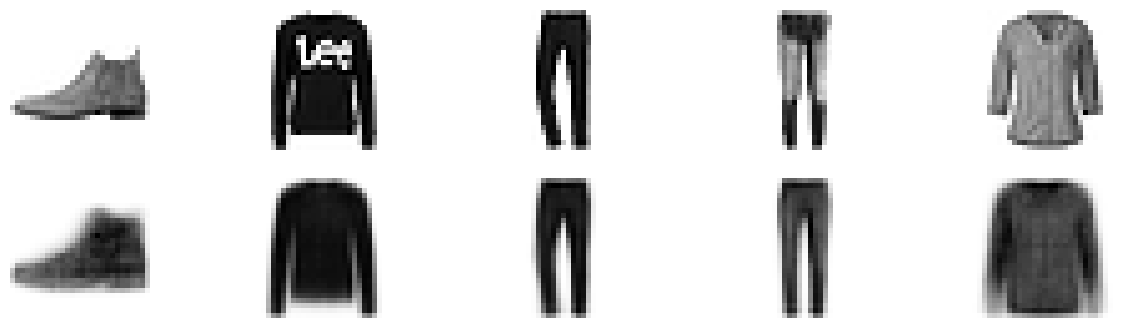

In [20]:
f, axs = plt.subplots(2, 5, figsize=(15, 4))
for j in range(5):
    axs[0, j].imshow(example_images[j].view(28, 28).numpy(), cmap='binary')
    axs[1, j].imshow(reconstructed_example_images[j].detach().numpy().squeeze(), cmap='binary')
    axs[0, j].axis('off')
    axs[1, j].axis('off')


Solo Decoder, un arreglo de números aleatorios (variables latentes), se usa para crear imágenes.

In [21]:
#
random_encodings = torch.tensor([[1, 1],
                                  [2, -2],
                                  [3, -3],
                                  [4, 4],
                                  [5, 1]], dtype=torch.float32)

reconstructed_example_images = decoder(random_encodings)

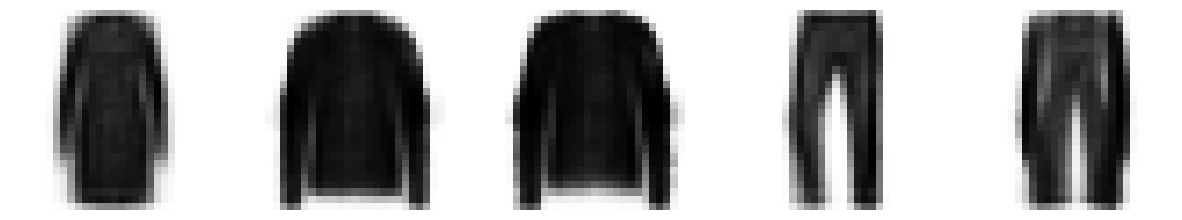

In [22]:
f, axs = plt.subplots(1, 5, figsize=(15, 4))
for j in range(5):
    axs[j].imshow(reconstructed_example_images[j].detach().numpy().squeeze(), cmap='binary')
    axs[j].axis('off')